In [6]:
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from scipy.stats import skew, kurtosis
from tensorflow.keras.utils import Sequence
import tensorflow as tf
tf.keras.backend.clear_session()

In [7]:
# Set parameters
image_size = (256, 256)  # Resize all images to this size
batch_size = 8
base_path = "/home/umar_ali/seml_2025/data/3_axes_spectrograms_odd"

train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2,  # Reserve 20% of the data for validation
)

train_generator = train_datagen.flow_from_directory(
    base_path,
    target_size=(image_size[0], image_size[1]),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    shuffle = False
)

# Create validation data generator
validation_generator = train_datagen.flow_from_directory(
    base_path,
    target_size=(image_size[0], image_size[1]),  # Resize images to the target size
    batch_size=batch_size,
    class_mode='binary',  # Binary classification
    subset='validation',  # This will use the validation subset
    shuffle = False
)

print("Class indices for training data:", train_generator.class_indices)
print("Class indices for validation data:", validation_generator.class_indices)

# Load a batch of images and labels
images, labels = next(train_generator)

# Print labels for this batch
print("Labels for the first batch:", labels)

sample_batch = next(train_generator)
print(sample_batch[0].shape)

print("Samples in training data:", train_generator.samples)
print("Samples in validation data:", validation_generator.samples)



# Helper function to extract statistical features
def extract_statistical_features(batch_images):
    # Initialize an empty list for features
    features = []
    for img in batch_images:
        img_flat = img.flatten()  # Flatten the image
        mean = np.mean(img_flat)
        std = np.std(img_flat)
        skewness = skew(img_flat)
        kurt = kurtosis(img_flat)
        # Append features for this image
        features.append([mean, std, skewness, kurt])
    return np.array(features)

class FeatureExtractionDataGenerator(Sequence):
    def __init__(self, image_generator):
        self.image_generator = image_generator

    def __len__(self):
        return len(self.image_generator)

    def __getitem__(self, index):
        # Get the next batch of images and labels
        batch_images, batch_labels = self.image_generator[index]
        # Extract statistical features
        features = extract_statistical_features(batch_images)
        # Return as a dictionary of inputs and labels
        return {"image_input": batch_images, "stat_input": features}, batch_labels


# Wrap the train and validation generators
train_feature_generator = FeatureExtractionDataGenerator(train_generator)
validation_feature_generator = FeatureExtractionDataGenerator(validation_generator)

# Example usage
sample_batch = train_feature_generator[0]
image_batch = sample_batch[0]["image_input"]  # Access image data
feature_batch = sample_batch[0]["stat_input"]  # Access statistical features
labels = sample_batch[1]  # Access labels

print("Image batch shape:", image_batch.shape)  # Shape of the images
print("Feature batch shape:", feature_batch.shape)  # Shape of the features
print("Labels shape:", labels.shape)  # Shape of the labels



Found 346 images belonging to 2 classes.
Found 86 images belonging to 2 classes.
Class indices for training data: {'class_0': 0, 'class_1': 1}
Class indices for validation data: {'class_0': 0, 'class_1': 1}
Labels for the first batch: [0. 0. 0. 0. 0. 0. 0. 0.]
(8, 256, 256, 3)
Samples in training data: 346
Samples in validation data: 86
Image batch shape: (8, 256, 256, 3)
Feature batch shape: (8, 4)
Labels shape: (8,)


In [8]:
from tensorflow.keras import layers, models

# Define image input branch
image_input = layers.Input(shape=(image_size[0], image_size[1], 3), name="image_input")
x = layers.Conv2D(32, (3, 3), activation="relu")(image_input)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.BatchNormalization()(x)
x = layers.Flatten()(x)
image_features = layers.Dense(64, activation="relu")(x)

# Define statistical features input branch
stat_input = layers.Input(shape=(4,), name="stat_input")
stat_features = layers.Dense(32, activation="relu")(stat_input)

# Concatenate image and statistical features
combined = layers.Concatenate()([image_features, stat_features])
x = layers.Dense(64, activation="relu")(combined)
output = layers.Dense(1, activation="sigmoid")(x)

# Create the model
model = models.Model(inputs=[image_input, stat_input], outputs=output)

# Compile the model
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Print model summary
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 254, 254,  │        896 │ image_input[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 127, 127,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 127, 127,  │        128 │ max_pooling2d[0]… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 516128)    │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stat_input          │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │ 33,032,256 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        160 │ stat_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 96)        │          0 │ dense[0][0],      │
│ (Concatenate)       │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      6,208 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         65 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 33,039,713 (126.04 MB)

 Trainable params: 33,039,649 (126.04 MB)

 Non-trainable params: 64 (256.00 B)

In [9]:
history = model.fit(
    train_feature_generator,
    validation_data=validation_feature_generator,
    epochs=12,
)


Epoch 1/12
44/44 ━━━━━━━━━━━━━━━━━━━━ 17s 263ms/step - accuracy: 0.5676 - loss: 28.0966 - val_accuracy: 0.5000 - val_loss: 2.1441
Epoch 2/12
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 212ms/step - accuracy: 0.9224 - loss: 0.4087 - val_accuracy: 0.5000 - val_loss: 4.9293
Epoch 3/12
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 208ms/step - accuracy: 0.9598 - loss: 0.2821 - val_accuracy: 0.5000 - val_loss: 1.1745
Epoch 4/12
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 224ms/step - accuracy: 0.9611 - loss: 0.1743 - val_accuracy: 0.5581 - val_loss: 0.9293
Epoch 5/12
44/44 ━━━━━━━━━━━━━━━━━━━━ 9s 211ms/step - accuracy: 1.0000 - loss: 5.2873e-04 - val_accuracy: 0.9767 - val_loss: 0.1396
Epoch 6/12
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 215ms/step - accuracy: 1.0000 - loss: 4.4007e-05 - val_accuracy: 0.9767 - val_loss: 0.1131
Epoch 7/12
44/44 ━━━━━━━━━━━━━━━━━━━━ 11s 247ms/step - accuracy: 1.0000 - loss: 2.2527e-05 - val_accuracy: 0.9884 - val_loss: 0.0939
Epoch 8/12
44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 221ms/step - accuracy: 1.0000 - loss: 3.3663e

In [13]:
# Save the model
model.save('CNN_with_feature_layers.h5')  # Saves in HDF5 format

In [10]:
# Wrap the validation generator
validation_feature_generator = FeatureExtractionDataGenerator(validation_generator)

# Evaluate the model
test_loss, test_acc = model.evaluate(validation_feature_generator)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.9970 - loss: 0.0155
Test Accuracy: 98.84%


11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        43
           1       1.00      0.98      0.99        43

    accuracy                           0.99        86
   macro avg       0.99      0.99      0.99        86
weighted avg       0.99      0.99      0.99        86

Precision: 1.0000
Recall: 0.9767
F1-Score: 0.9882
ROC AUC: 0.9884


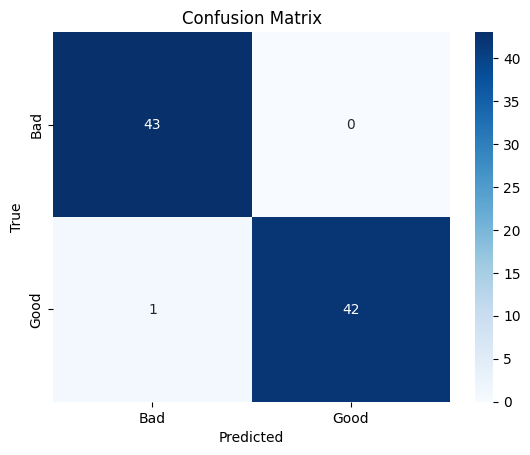

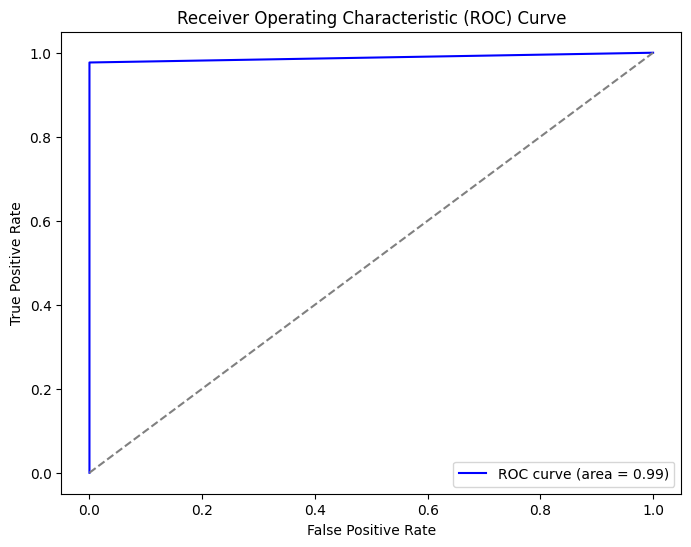

In [11]:

# Get the true labels from the original generator
true_labels = validation_generator.classes  # Actual labels

# Get predictions from the model
predictions = model.predict(validation_feature_generator, verbose=1)

# Convert probabilities to binary labels (0 or 1) based on a threshold of 0.5
predictions = (predictions >= 0.5).astype(int).flatten()  # Flatten for compatibility

# Compute the confusion matrix
cm = confusion_matrix(true_labels, predictions)

# Import required libraries
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Compute metrics
precision = precision_score(true_labels, predictions)
recall = recall_score(true_labels, predictions)
f1 = f1_score(true_labels, predictions)
roc_auc = roc_auc_score(true_labels, predictions)

# Print classification report
print("Classification Report:")
print(classification_report(true_labels, predictions))

# Print individual metrics
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

# Plot the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Bad', 'Good'], yticklabels=['Bad', 'Good'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Calculate and plot ROC curve
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(true_labels, predictions)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


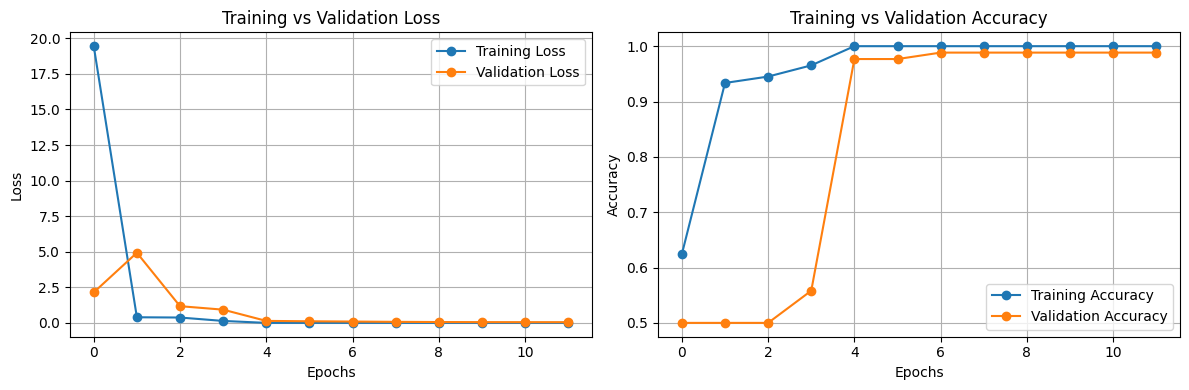

In [12]:
plt.figure(figsize=(12, 4))

# Plot training and validation loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()